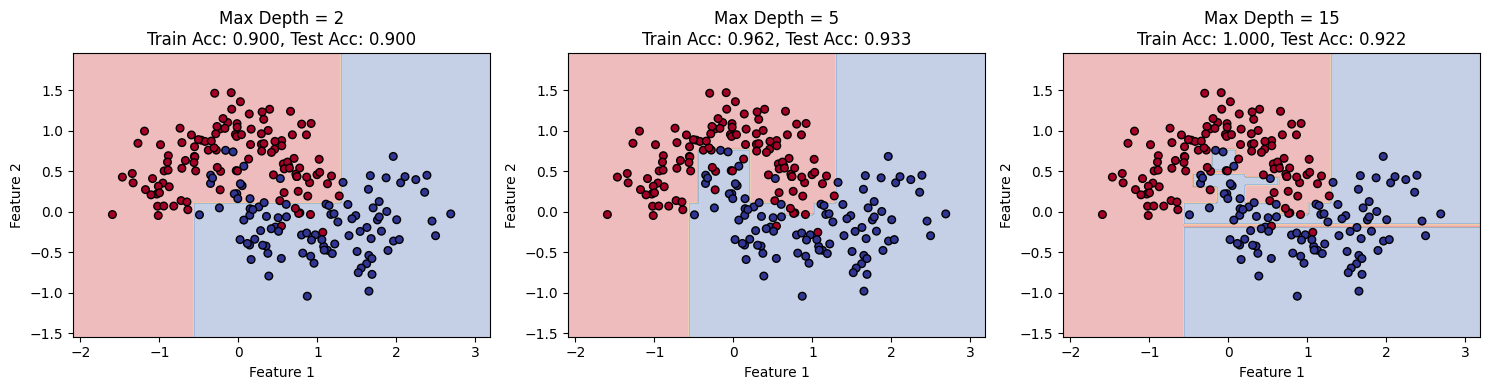

In [1]:
# 1. 导入库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 2. 生成一个复杂的非线性数据集（月牙形）
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. 定义一个绘制决策边界函数
def plot_decision_boundary(clf, X, y, ax, title):
    # 创建网格点
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    # 预测整个网格
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    # 绘制决策边界和样本点
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolors='k', cmap=plt.cm.RdYlBu)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

# 4. 训练不同复杂度的模型并绘图
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
max_depths = [2, 5, 15] # 分别对应欠拟合、适中、过拟合

for i, depth in enumerate(max_depths):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    # 计算准确率
    train_acc = accuracy_score(y_train, dt.predict(X_train))
    test_acc = accuracy_score(y_test, dt.predict(X_test))
    title = f"Max Depth = {depth}\nTrain Acc: {train_acc:.3f}, Test Acc: {test_acc:.3f}"
    plot_decision_boundary(dt, X_train, y_train, axes[i], title)

plt.tight_layout()
plt.show()

In [2]:
# 1. 导入交叉验证相关库
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 2. 使用一个更复杂的数据集（手写数字识别简化版）
from sklearn.datasets import load_digits
digits = load_digits()
X, y = digits.data, digits.target
print(f"手写数字数据集形状: {X.shape}") # 64个特征（8x8像素）

# 3. 数据标准化（很多模型需要，如逻辑回归）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. 使用5折交叉验证评估逻辑回归模型
# 创建模型
log_reg = LogisticRegression(max_iter=5000, random_state=42)
# 进行交叉验证，评估指标为准确率
cv_scores = cross_val_score(log_reg, X_scaled, y, cv=5, scoring='accuracy')
# cv=5 表示5折交叉验证
# scoring='accuracy' 表示用准确率评估

print(f"交叉验证准确率分数: {cv_scores}")
print(f"交叉验证平均准确率: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})") # 输出均值±两倍标准差

手写数字数据集形状: (1797, 64)
交叉验证准确率分数: [0.91666667 0.87777778 0.94150418 0.9637883  0.89415042]
交叉验证平均准确率: 0.9188 (+/- 0.0622)


In [3]:
import tensorflow as tf
from tensorflow import kears
import numpy as np
import matplotlib.pyplot as plt
print(f"TensorFlow 版本：{tf.__version__}")

mnist=kears.datasets.mnist
(X_train_full,y_train_full),(X_test,y_test)=mnist.load_data()

print(f"\n训练集数据形状：{X_train_full.shape}")
print(f"训练集标签形状：{y_train_full.shape}")
print(f"测试集数据形状：{X_test.shape}")

plt.imshow(X_train_full[0],cmap='gray')
plt.title(f"标签：{y_train_full[0]}")
plt.axis('off')
plt.show()



I0000 00:00:1775291091.732733   26027 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775291092.293303   26027 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775291095.721912   26027 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


ImportError: cannot import name 'kears' from 'tensorflow' (/home/adorukw/anaconda3/envs/ai_study/lib/python3.10/site-packages/tensorflow/__init__.py)